# Landscape Classification with ResNet

## 1. Introduction

The goal of this project is training a deep learning model for Intel Image Classification, which classifies images into six categories: Building, Forest, Glacier, Mountain, Sea, and Street. Using the ResNet-50 model, the goal is to achieve high accuracy by leveraging transfer learning. The dataset consists of training and validation subsets, enabling model evaluation and fine-tuning. The main questions are;
Can we achieve accurate image classification with a ResNet model?
How well does ResNet-50 perform on this dataset?"


We connect Google Drive to access the dataset stored in the designated directory. Additionally, we install and import the required libraries necessary for preprocessing, modeling, and training.

Dataset: https://www.kaggle.com/datasets/puneet6060/intel-image-classification


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torchvision torch matplotlib scikit-learn tqdm

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm
import os


Mounted at /content/drive


## 2. Loading and Import Data
The dataset is stored in Google Drive and loaded using PyTorch's ImageFolder for structured datasets. It includes a training and validation directory, organized into folders for each class.

The Intel Image Classification dataset was loaded using the ImageFolder class from torchvision.datasets. The images were resized to 224x224 pixels and normalized according to the ResNet-50 pre-trained model's requirements. The training and validation sets were then prepared using PyTorch's DataLoader class.

We specify the directory where our dataset is stored and perform data transformation operations such as resizing and normalization. Using the ImageFolder class, we load the dataset into a structured format, making it ready for training and validation.





In [ ]:
base_dir = '/content/drive/MyDrive/intel-image-classification'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet için uygun boyut
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = torchvision.datasets.ImageFolder(root=val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


## 3. Custom Dataset

The dataset contains images grouped into six classes, as specified. To ensure uniform input size for the ResNet-50 model, images are resized and normalized.

In this section, ResNet-50 model is loaded and we modify the final fully connected layer to match the number of classes in our dataset within 6 classes.

The ResNet-50 model was used with its final layer replaced to accommodate six output classes. Transfer learning is applied using pretrained weights.

The model was trained using the Adam optimizer with a learning rate of 0.001. Cross-entropy loss was used as the loss function, and the model was trained for 10 epochs.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(pretrained=True)

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


## 4. Training

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_losses.append(train_loss / len(train_loader))

        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                val_preds.extend(torch.argmax(outputs, axis=1).cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        val_losses.append(val_loss / len(val_loader))
        val_accuracy = accuracy_score(val_targets, val_preds)

        print(f"Epoch {epoch+1}: Train Loss = {train_losses[-1]:.4f}, Val Loss = {val_losses[-1]:.4f}, Val Accuracy = {val_accuracy:.4f}")

    return train_losses, val_losses, val_targets, val_preds

train_losses, val_losses, val_targets, val_preds = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)


Epoch 1/10:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.6885, Val Loss = 0.8061, Val Accuracy = 0.7267


Epoch 2/10:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.4514, Val Loss = 0.5138, Val Accuracy = 0.8079


Epoch 3/10:   0%|          | 0/188 [00:00<?, ?it/s]

...

Epoch 8: Train Loss = 0.2058, Val Loss = 0.4431, Val Accuracy = 0.8542


Epoch 9/10:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 9: Train Loss = 0.1850, Val Loss = 0.4219, Val Accuracy = 0.8617


Epoch 10/10:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 10: Train Loss = 0.1418, Val Loss = 0.5577, Val Accuracy = 0.8462


## 5. Plotting Training and Validation Loss

We use matplotlib to visualize the training and validation losses.


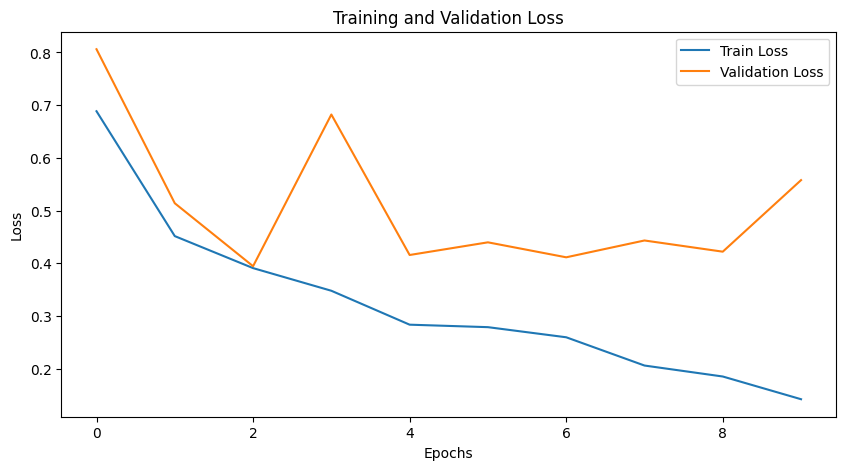

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


### A subset of 25 random images from the training dataset was visualized along with their corresponding labels. This helped to understand the dataset and check if the images are being loaded correctly.

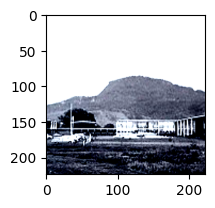

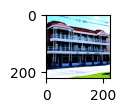

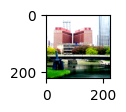

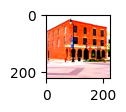

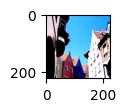

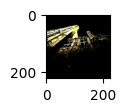

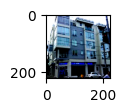

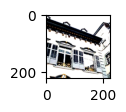

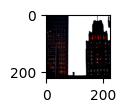

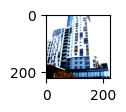

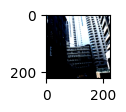

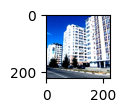

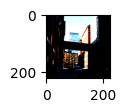

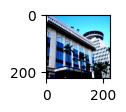

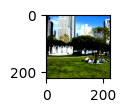

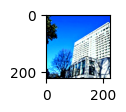

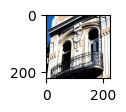

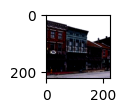

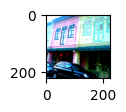

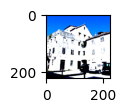

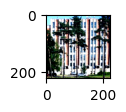

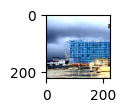

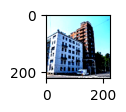

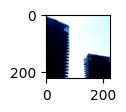

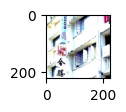

In [ ]:
def imshow(img):
    # ResNet'teki normalizasyonu tersine çevirme
    img = img / 2 + 0.5  # denormalizasyon
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

def plot_images(images, labels, classes, n_images=25):
    plt.figure(figsize=(12, 12))
    for i in range(n_images):
        ax = plt.subplot(5, 5, i+1)  # 5x5 grid
        imshow(images[i])
        ax.set_title(classes[labels[i]])
        ax.axis('off')
    plt.show()

N_IMAGES = 25
images, labels = zip(*[(image, label) for image, label in
                       [train_dataset[i] for i in range(N_IMAGES)]])

classes = train_dataset.classes

plot_images(images, labels, classes)


## 6. Saving and Loading the Model
We save the trained model and later reload it for use. This step ensures the model can be reused after training is completed.

After training, the model's weights were saved using torch.save. The saved model can be loaded later using torch.load, which allows us to reuse the model without retraining.

In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/intel-image-classification/model.pth')

model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(torch.load('/content/drive/MyDrive/intel-image-classification/model.pth'))
model = model.to(device)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-7-5be76dbb209d>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions 

## 7. Model Evaluation
We evaluate the results on the validation dataset using the trained and saved model.


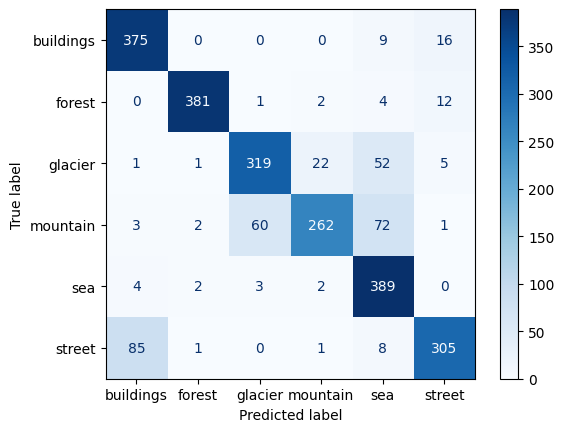

{'precision macro': 0.8589033627209007, 'recall macro': 0.8462500000000001, 'f1 macro': 0.8443404398084167, 'accuracy': 0.84625}


In [ ]:
def get_result(model, data, device, classes):
    predict = None
    gold = None
    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in data:

            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)
            top_pred = y_pred.argmax(1, keepdim=True)
            if predict is None:
                predict = top_pred
                gold = y
            else:
                predict = torch.cat([predict, top_pred])
                gold = torch.cat([gold, y])

    predict = predict.cpu()
    gold = gold.cpu()

    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    precision_macro = precision_score(gold, predict, average='macro')
    recall_macro = recall_score(gold, predict, average='macro')
    f1_macro = f1_score(gold, predict, average='macro')
    accuracy = accuracy_score(gold, predict)

    from sklearn.metrics import ConfusionMatrixDisplay
    ConfusionMatrixDisplay.from_predictions(gold, predict, display_labels=classes, cmap=plt.cm.Blues)
    plt.show()

    return {"precision macro": precision_macro, "recall macro": recall_macro, "f1 macro": f1_macro, "accuracy": accuracy}

result = get_result(model, val_loader, device, train_dataset.classes)
print(result)


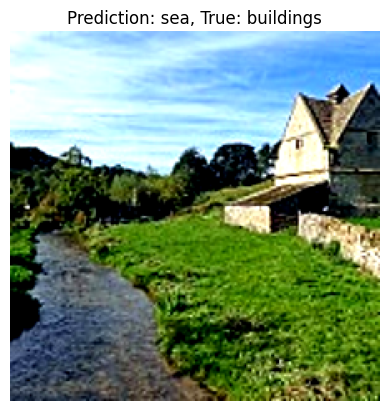

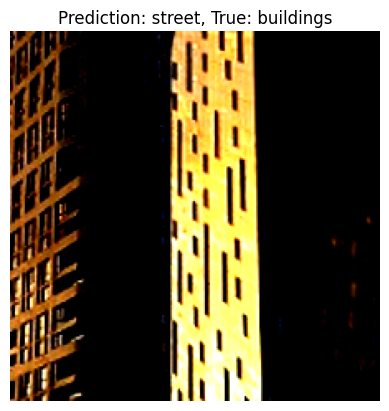

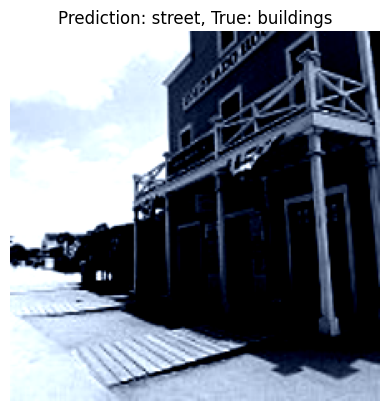

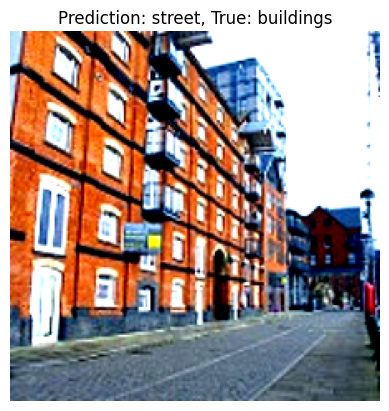

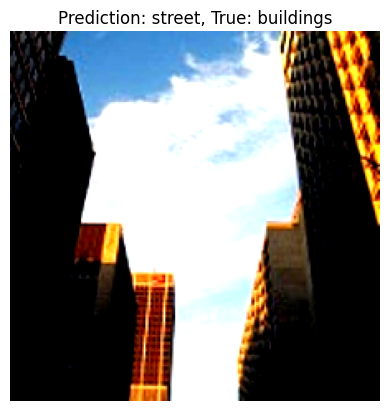

In [ ]:
def show_misclassified_images(model, val_loader, device, classes):
    model.eval()
    misclassified = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, axis=1)
            for img, pred, true in zip(inputs, preds, labels):
                if pred != true:
                    misclassified.append((img.cpu(), pred.cpu(), true.cpu()))
    for i in range(min(5, len(misclassified))):
        img, pred, true = misclassified[i]
        plt.imshow(np.transpose(img.numpy(), (1, 2, 0)) * 0.5 + 0.5)  # Denormalizasyon
        plt.title(f"Prediction: {classes[pred]}, True: {classes[true]}")
        plt.axis('off')
        plt.show()

show_misclassified_images(model, val_loader, device, train_dataset.classes)



Ibrahim Kilic
5209813